1.Converter a imagem para Escala de Cinza (Hough trabalha com gradientes de intensidade, não cores).

2.Aplicar um Blur (Desfoque) para reduzir ruído (essencial para evitar falsos positivos).

3.Usar cv2.HoughCircles para detectar círculos.

4.Como o enunciado pede a placa mais próxima, selecionar o círculo com o maior raio.

5.Exibir a imagem resultante destacando a placa

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Imagem passada para cinza


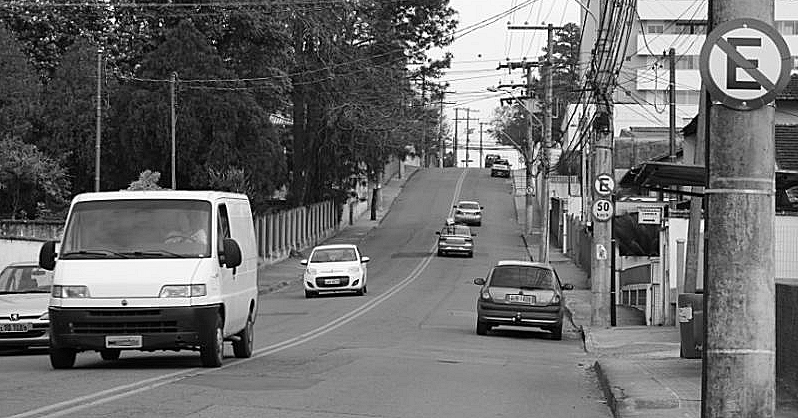

Imagem cinza apos o borramento


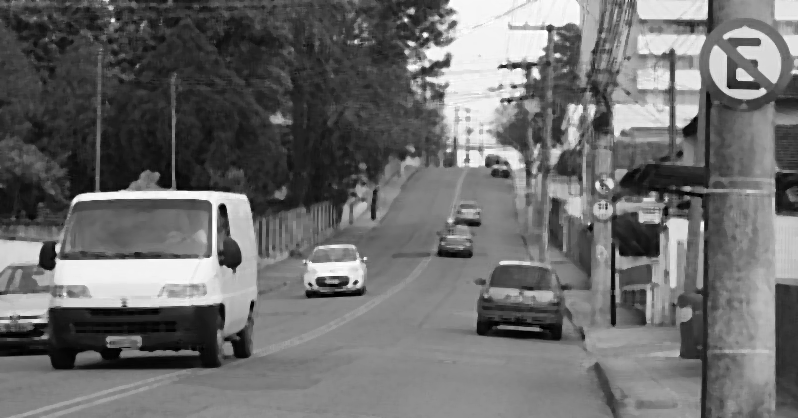



Circulos encontrados:
Foram encontrados 2 circulos
Centro: (744, 64), Raio: 47
Centro: (374, 146), Raio: 39


Placa detectada! Centro: (744, 64), Raio: 47




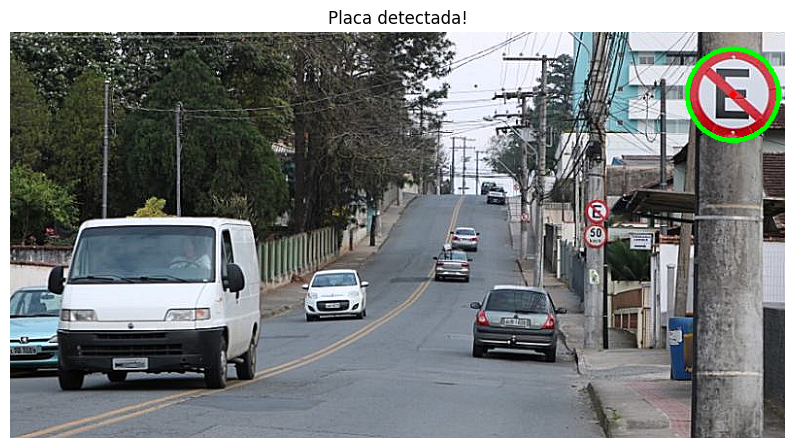

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

#Carrega a imagem
img = cv2.imread('/content/drive/MyDrive/Pesquisa/Visão Computacional/imagens/Quest2/placas.png')

output = img.copy()

# 1. passa para a escala de cinza
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Imagem passada para cinza")
cv2_imshow(gray)

# 2. Aplicar Blur é CRUCIAL para Hough funcionar bem (reduz ruído)
gray_blurred = cv2.medianBlur(gray, 5)

print("Imagem cinza apos o borramento")
cv2_imshow(gray_blurred)


# 3. Aplicar Transformada de Hough para Círculos
# dp: Razão inversa da resolução (1 = mesma resolução da imagem)
# minDist: Distância mínima entre os centros dos círculos detectados
# param1: Limiar superior para o detector de bordas Canny interno
# param2: Limiar do acumulador (quanto menor, mais círculos falsos; quanto maior, mais rigoroso)
circles = cv2.HoughCircles(gray_blurred,
                           cv2.HOUGH_GRADIENT,
                           dp=1,
                           minDist=100,
                           param1=40,
                           param2=60,
                           minRadius=20,
                           maxRadius=70) # Ajuste maxRadius para evitar pegar objetos gigantes irrelevantes


if circles is not None:
    # Converter coordenadas para inteiros (arredondar)
    circles = np.round(circles[0, :]).astype("int")
    print("\n")
    print("Circulos encontrados:")
    print(f"Foram encontrados {len(circles)} circulos")
    for (x, y, r) in circles:
        print(f"Centro: ({x}, {y}), Raio: {r}")

    # 4. Lógica da "Mais Próxima": Encontrar o círculo com MAIOR RAIO (r)
    # O array circles retorna (x, y, raio)

    melhor_circulo = None
    maior_raio = 0

    for (x, y, r) in circles:
        if r > maior_raio:
            maior_raio = r
            melhor_circulo = (x, y, r)

    # Desenhar apenas o maior círculo encontrado
    if melhor_circulo is not None:
        (x, y, r) = melhor_circulo

        # Desenhar o círculo da placa
        cv2.circle(output, (x, y), r, (0, 255, 0), 4)
        # Desenhar o ponto central
        cv2.circle(output, (x, y), 2, (0, 0, 255), 3)

        print("\n")
        print(f"Placa detectada! Centro: ({x}, {y}), Raio: {r}")
        print("\n")

# 5. Exibir resultado
img_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.title("Placa detectada!")
plt.axis('off')
plt.show()